# F1-SIS: Safety Car Occurrence Probability Model

**Capstone Project: Formula 1 Strategy Intelligence System**  
**Module: SC/VSC Probabilistic Forecasting**

---

## 1. Project Objective

At the end of every completed race lap $t$, estimate:

$$P(\text{SC occurs within next } n \text{ laps} \mid H_t, C, R_t)$$

for horizons $n \in \{1, 3, 5, 10\}$, producing continuous probabilities:

| Output | Meaning |
|--------|---------|
| `P_SC_1` | Probability of a NEW SC in the next 1 lap |
| `P_SC_3` | Probability of a NEW SC in the next 3 laps |
| `P_SC_5` | Probability of a NEW SC in the next 5 laps |
| `P_SC_10` | Probability of a NEW SC in the next 10 laps |

**Example output at lap 42:**
```
F1-SIS SAFETY CAR RISK FORECAST
Race: Example GP  |  Current Lap: 42
  Next 1 lap  :  2.4%
  Next 3 laps :  6.8%
  Next 5 laps : 11.7%
  Next 10 laps: 24.9%
```

> **CRITICAL**: The model output is always a probability, never a binary SC=0/1 label.
> Boolean labels exist only as internal training/evaluation ground-truth.


---

## 2. Research Question

**Core question:**

> *Can the probability of a future Safety Car occurrence be estimated in real time
> from the evolving race state and historical race characteristics?*

Formally, the model estimates:

$$P(SC_{t+1:t+n} = 1 \mid H_t, C, R_t)$$

where:
- $H_t = \{S_1, S_2, \ldots, S_t\}$ is the complete observed race history through lap $t$
- $C$ is historical/circuit context
- $R_t$ is the current race state

**What this model predicts:** SC *occurrence* (whether a new event starts)

**What this model does NOT predict:** SC *duration* (outside scope)


---

## 3. Literature Foundation

### Heilmeier et al. - Monte Carlo Race Simulation

Heilmeier et al. model SC phases probabilistically in an **offline** race simulator,
using race-progress groups (Lap 1, 2-20%, 20-40%, ...) to estimate SC-start probabilities.

**This project extends that concept:** rather than static offline probabilities,
F1-SIS conditions the forecast on the *evolving observed race state* in real time.

| Heilmeier | F1-SIS Extension |
|-----------|------------------|
| Offline simulation | Real-time forecasting |
| Race-progress groups only | Full race history + circuit context |
| Fixed historical priors | State-conditioned hazard model |

### Other Supporting Literature

- **Decision Support Systems for Time Series in Sport** - sequential data, real-time decision architecture
- **Sequential Decision Making under Uncertainty** - state evolution, cumulative information
- **Pit Stop DSS (GRU/LSTM/TCN)** - temporal F1 modelling, class imbalance (SMOTE for pit decisions,
  referenced as methodological context only - not as proof that XGBoost + SMOTE is best for SC)
- **Explainable AI in high-stakes decisions** - explanation layer for strategy outputs

> **Important distinction:** No single paper directly proposes the F1-SIS architecture.
> This notebook represents a novel synthesis and extension of the literature.


---

## 4. Problem Definition

### Hazard-Based Formulation

Define the SC hazard at future lap $t+k$:

$$h(t+k) = P(\text{SC starts at lap } t+k \mid \text{no new SC before } t+k, H_t)$$

The cumulative probability of at least one new SC within $n$ future laps:

$$P_{SC,n} = 1 - \prod_{k=1}^{n} (1 - h(t+k))$$

This naturally guarantees monotonicity:

$$P_{SC,1} \leq P_{SC,3} \leq P_{SC,5} \leq P_{SC,10}$$

### Why Hazard?

Training 4 independent binary classifiers and calling outputs 'probabilities' is incorrect:
it does not enforce monotonicity and does not represent the correct conditional structure.
The hazard formulation ensures the probabilities are internally consistent.

### Prediction Timestamp

Predictions are generated at the **end of each completed lap**.
At lap $t$, all information through lap $t$ is available. No lap $t+1$ information may be used.


---

## 5. SC vs VSC Event Definition

### TrackStatus Encoding

FastF1 `TrackStatus` uses concatenated digit codes:

| Digit | Meaning |
|-------|---------|
| `1` | Track clear (green) |
| `2` | Yellow flag |
| `4` | Safety Car active |
| `5` | Red flag |
| `6` | VSC deployed |
| `7` | VSC ending |

A TrackStatus of `24` means both yellow flag AND SC active.

### SC Event Definition

```
Lap 30: normal         
Lap 31: normal         
Lap 32: SC active  <-- SC START (sc_started = 1)
Lap 33: SC active  <-- same event
Lap 34: SC active  <-- same event
Lap 35: normal     <-- SC END
```

This is **ONE** SC event. Each driver-lap row is NOT a separate occurrence.

### VSC Handling

- `6` = VSC deployed (new VSC start if previous lap was not VSC)
- `7` = VSC ending (NOT a new event; same VSC event continuing to close)

VSC and SC are modelled **separately**. SC is the primary target.
VSC history is a valid feature for SC forecasting.


---

## 6. Configuration & Imports


In [1]:
import os, warnings, json
from pathlib import Path
from itertools import product as iproduct

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ML
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.isotonic import IsotonicRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    brier_score_loss, average_precision_score, roc_auc_score,
    precision_recall_curve, log_loss
)

try:
    import catboost as cb
    CATBOOST_AVAILABLE = True
    print('CatBoost:', cb.__version__)
except ImportError:
    CATBOOST_AVAILABLE = False
    print('CatBoost not available.')

try:
    import torch
    import torch.nn as nn
    TORCH_AVAILABLE = True
    print('PyTorch:', torch.__version__)
except ImportError:
    TORCH_AVAILABLE = False
    print('PyTorch not available.')

try:
    import shap
    SHAP_AVAILABLE = True
    print('SHAP:', shap.__version__)
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP not available.')

print('NumPy:', np.__version__)
print('Pandas:', pd.__version__)
print('XGBoost:', xgb.__version__)


CatBoost: 1.2.10
PyTorch: 2.13.0+cpu
SHAP: 0.52.0
NumPy: 2.5.1
Pandas: 2.3.3
XGBoost: 3.4.0


In [2]:
# ─── Central Configuration ───────────────────────────────────────────────
DATA_DIR    = os.path.join('data_fastf1_v1', 'laps')
MODEL_DIR   = 'models'
HORIZONS    = [1, 3, 5, 10]   # Prediction horizons (laps)
MAX_HORIZON = max(HORIZONS)
RANDOM_SEED = 42
TARGET      = 'SC'

# Season split
TRAIN_SEASONS = [2018, 2019, 2020, 2021, 2022]
VAL_SEASONS   = [2023]
TEST_SEASONS  = [2024]

# Progress bins (matching Heilmeier et al. methodology)
PROGRESS_BINS   = [0, 0.01, 0.20, 0.40, 0.60, 0.80, 1.01]
PROGRESS_LABELS = ['Lap1', '2-20', '20-40', '40-60', '60-80', '80-100']

os.makedirs(MODEL_DIR, exist_ok=True)
print('Configuration set.')
print(f'  Horizons : {HORIZONS}')
print(f'  Train    : {TRAIN_SEASONS}')
print(f'  Val      : {VAL_SEASONS}')
print(f'  Test     : {TEST_SEASONS}')


Configuration set.
  Horizons : [1, 3, 5, 10]
  Train    : [2018, 2019, 2020, 2021, 2022]
  Val      : [2023]
  Test     : [2024]


---

## 7. Data Loading


In [3]:
def load_race_data(data_dir=DATA_DIR):
    frames = []
    data_path = Path(data_dir)
    if not data_path.exists():
        raise FileNotFoundError(f'Data directory not found: {data_dir}')

    for season_dir in sorted(data_path.iterdir()):
        if not season_dir.is_dir():
            continue
        try:
            year = int(season_dir.name)
        except ValueError:
            continue
        for csv_file in sorted(season_dir.glob('*.csv')):
            try:
                df = pd.read_csv(csv_file, low_memory=False)
                df['Year']     = year
                df['RaceName'] = csv_file.stem
                df['race_id']  = f'{year}_{csv_file.stem}'
                frames.append(df)
            except Exception as e:
                print(f'  WARNING: {csv_file.name}: {e}')

    if not frames:
        raise FileNotFoundError(f'No race CSVs found in {data_dir}')

    df_all = pd.concat(frames, ignore_index=True)
    print(f'Loaded {len(frames)} races across {df_all["Year"].nunique()} seasons')
    print(f'Total driver-lap rows: {len(df_all):,}')
    return df_all


df_raw = load_race_data()


Loaded 172 races across 8 seasons
Total driver-lap rows: 188,482


---

## 8. Data Inspection


In [4]:
def inspect_dataset(df):
    print('=== Dataset Overview ===')
    print(f'Rows         : {len(df):,}')
    print(f'Columns      : {list(df.columns)}')
    print(f'Seasons      : {sorted(df["Year"].unique())}')
    print(f'Races        : {df["race_id"].nunique()}')
    print()

    # Required columns
    required = ['LapNumber', 'TrackStatus', 'Driver', 'Year', 'race_id']
    missing = [c for c in required if c not in df.columns]
    if missing:
        print(f'WARNING - missing required columns: {missing}')
    else:
        print('All required columns present.')

    # TrackStatus sample values
    print()
    print('TrackStatus unique values (sample):')
    ts_counts = df['TrackStatus'].value_counts().head(20)
    print(ts_counts.to_string())
    return df


df_raw = inspect_dataset(df_raw)


=== Dataset Overview ===
Rows         : 188,482
Columns      : ['Year', 'GrandPrix', 'Round', 'Country', 'Location', 'Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'DriverFullName', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate', 'AirTemp', 'Humidity', 'Pressure', 'Rainfall', 'TrackTemp', 'WindDirection', 'WindSpeed', 'HasGreen', 'HasYellow', 'HasSafetyCar', 'HasRedFlag', 'HasVSC', 'HasVSCEnding', 'GapToLeader', 'IntervalToPositionAhead', 'GapToLeaderSeconds', 'IntervalToPositionAheadSeconds', 'TimeSeconds', 'LapTimeSeconds', 'PitInTimeSeconds', 'PitOutTimeSeconds', 'Sector1TimeSeconds', 'Sector2TimeSeconds', 'Sector3TimeSeconds', 'Sector1SessionTimeSecon

---

## 9. TrackStatus Decoding

TrackStatus can contain concatenated codes. We check for digit membership:

```python
'124' contains digit '4'  -> SC active
'67'  contains digit '6'  -> VSC deployed
```


In [5]:
# Known digit codes
TS_GREEN      = '1'
TS_YELLOW     = '2'
TS_SC         = '4'
TS_RED        = '5'
TS_VSC        = '6'
TS_VSC_ENDING = '7'

KNOWN_DIGITS = set('12345678')


def decode_track_status(status_series):
    s = status_series.astype(str).str.strip()

    # Warn on unexpected characters
    all_chars = set(''.join(s.unique()))
    unexpected = all_chars - KNOWN_DIGITS - {' ', 'n', 'a', 'N'}  # nan
    if unexpected:
        print(f'  WARNING: unexpected TrackStatus characters: {unexpected}')

    sc_active  = s.str.contains(TS_SC,         na=False)
    vsc_active = s.str.contains(TS_VSC,        na=False)
    vsc_ending = s.str.contains(TS_VSC_ENDING, na=False)
    yellow     = s.str.contains(TS_YELLOW,     na=False)
    red_flag   = s.str.contains(TS_RED,        na=False)

    return pd.DataFrame({
        'sc_active' : sc_active,
        'vsc_active': vsc_active,
        'vsc_ending': vsc_ending,
        'yellow'    : yellow,
        'red_flag'  : red_flag,
    })


# Validate on sample races
decoded_sample = decode_track_status(df_raw['TrackStatus'])
print('TrackStatus decoded. Summary:')
print(decoded_sample.sum())


TrackStatus decoded. Summary:
sc_active     10551
vsc_active     3344
vsc_ending     1639
yellow        10783
red_flag        426
dtype: int64


---

## 10. Race-Level Aggregation

The CSV is driver-lap level. We aggregate to **one row per race lap**,
since TrackStatus applies to the whole field.


In [6]:
def build_race_level_timeline(df):
    df = df.copy()
    df['LapNumber'] = pd.to_numeric(df['LapNumber'], errors='coerce')
    df = df.dropna(subset=['LapNumber', 'race_id'])
    df['LapNumber'] = df['LapNumber'].astype(int)

    # Decode track status
    decoded = decode_track_status(df['TrackStatus'])
    for col in decoded.columns:
        df[col] = decoded[col]

    # Per-lap numeric columns
    for col in ['LapTimeSeconds', 'TyreLife', 'AirTemp', 'TrackTemp',
                'Humidity', 'WindSpeed']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Rainfall (may be string 'True'/'False' or bool)
    if 'Rainfall' in df.columns:
        df['Rainfall'] = df['Rainfall'].astype(str).str.lower().isin(['true', '1', 'yes'])

    # PitInTime - detect pit stops
    if 'PitInTime' in df.columns:
        df['pitted'] = df['PitInTime'].notna()
    else:
        df['pitted'] = False

    # Group to race-lap level
    grp = df.groupby(['race_id', 'Year', 'RaceName', 'LapNumber'])

    agg = grp.agg(
        sc_active     = ('sc_active',        'any'),
        vsc_active    = ('vsc_active',        'any'),
        vsc_ending    = ('vsc_ending',        'any'),
        yellow        = ('yellow',            'any'),
        red_flag      = ('red_flag',          'any'),
        n_cars        = ('Driver',            'nunique'),
        lap_time_med  = ('LapTimeSeconds',    'median'),
        lap_time_std  = ('LapTimeSeconds',    'std'),
        lap_time_min  = ('LapTimeSeconds',    'min'),
        tyre_age_med  = ('TyreLife',           'median'),
        tyre_age_max  = ('TyreLife',           'max'),
        air_temp      = ('AirTemp',            'median'),
        track_temp    = ('TrackTemp',          'median'),
        humidity      = ('Humidity',           'median'),
        rainfall      = ('Rainfall',           'any'),
        total_pits    = ('pitted',             'sum'),
    ).reset_index()

    # Total laps per race
    max_laps = df.groupby('race_id')['LapNumber'].max().rename('total_laps').reset_index()
    agg = agg.merge(max_laps, on='race_id', how='left')
    agg['race_progress'] = agg['LapNumber'] / agg['total_laps']

    # Peak cars for retirement count
    agg = agg.sort_values(['race_id', 'LapNumber'])
    agg['peak_cars']   = agg.groupby('race_id')['n_cars'].transform('cummax')
    agg['retirements'] = (agg['peak_cars'] - agg['n_cars']).clip(lower=0)

    print(f'Race-level timeline: {len(agg):,} rows across {agg["race_id"].nunique()} races')
    return agg


df_laps = build_race_level_timeline(df_raw)
print(df_laps.head(3).T)


Race-level timeline: 10,317 rows across 172 races
                                       0                          1  \
race_id        2018_Abu_Dhabi_Grand_Prix  2018_Abu_Dhabi_Grand_Prix   
Year                                2018                       2018   
RaceName            Abu_Dhabi_Grand_Prix       Abu_Dhabi_Grand_Prix   
LapNumber                              1                          2   
sc_active                           True                       True   
vsc_active                         False                      False   
vsc_ending                         False                      False   
yellow                              True                      False   
red_flag                           False                      False   
n_cars                                20                         19   
lap_time_med                     153.936                        NaN   
lap_time_std                    9.082729                        NaN   
lap_time_min               

---

## 11. SC/VSC Event Detection


In [7]:
def detect_sc_events(df):
    df = df.sort_values(['race_id', 'LapNumber']).copy()
    df['sc_prev']    = df.groupby('race_id')['sc_active'].shift(1, fill_value=False)
    df['sc_started'] = (~df['sc_prev']) & df['sc_active']
    df['sc_ended']   = df['sc_prev']   & (~df['sc_active'])

    # Assign event IDs
    df['sc_event_id'] = df.groupby('race_id')['sc_started'].cumsum()
    df.loc[~df['sc_active'], 'sc_event_id'] = 0

    df['sc_started'] = df['sc_started'].astype(int)
    df['sc_ended']   = df['sc_ended'].astype(int)
    df.drop(columns=['sc_prev'], inplace=True)
    return df


def detect_vsc_events(df):
    df = df.sort_values(['race_id', 'LapNumber']).copy()
    # VSC active but NOT ending (digit 7 = same event winding down)
    df['vsc_truly_active'] = df['vsc_active'] & ~df['vsc_ending']
    df['vsc_prev']         = df.groupby('race_id')['vsc_truly_active'].shift(1, fill_value=False)
    df['vsc_started']      = (~df['vsc_prev']) & df['vsc_truly_active']
    df['vsc_ended']        = df['vsc_prev']    & (~df['vsc_truly_active'])

    df['vsc_event_id'] = df.groupby('race_id')['vsc_started'].cumsum()
    df.loc[~df['vsc_truly_active'], 'vsc_event_id'] = 0

    df['vsc_started'] = df['vsc_started'].astype(int)
    df['vsc_ended']   = df['vsc_ended'].astype(int)
    df.drop(columns=['vsc_prev'], inplace=True)
    return df


def build_event_table(df):
    sc_events = []
    for race_id, grp in df[df['sc_event_id'] > 0].groupby(['race_id', 'sc_event_id']):
        sc_events.append({
            'race_id'      : race_id[0],
            'sc_event_id'  : race_id[1],
            'sc_start_lap' : grp['LapNumber'].min(),
            'sc_end_lap'   : grp['LapNumber'].max(),
            'sc_duration'  : grp['LapNumber'].max() - grp['LapNumber'].min() + 1,
        })
    vsc_events = []
    for race_id, grp in df[df['vsc_event_id'] > 0].groupby(['race_id', 'vsc_event_id']):
        vsc_events.append({
            'race_id'       : race_id[0],
            'vsc_event_id'  : race_id[1],
            'vsc_start_lap' : grp['LapNumber'].min(),
            'vsc_end_lap'   : grp['LapNumber'].max(),
            'vsc_duration'  : grp['LapNumber'].max() - grp['LapNumber'].min() + 1,
        })
    return pd.DataFrame(sc_events), pd.DataFrame(vsc_events)


df_laps = detect_sc_events(df_laps)
df_laps = detect_vsc_events(df_laps)
sc_events, vsc_events = build_event_table(df_laps)

print(f'SC events detected : {len(sc_events)}')
print(f'VSC events detected: {len(vsc_events)}')
print(f'Races with SC      : {sc_events["race_id"].nunique() if len(sc_events) else 0}')
print()
if len(sc_events):
    print('SC Event Table (sample):')
    print(sc_events.head(10).to_string(index=False))


SC events detected : 128
VSC events detected: 74
Races with SC      : 97

SC Event Table (sample):
                   race_id  sc_event_id  sc_start_lap  sc_end_lap  sc_duration
 2018_Abu_Dhabi_Grand_Prix            1             1           4            4
2018_Australian_Grand_Prix            1            26          31            6
2018_Azerbaijan_Grand_Prix            1             1           5            5
2018_Azerbaijan_Grand_Prix            2            38          47           10
   2018_Belgian_Grand_Prix            1             1           4            4
   2018_British_Grand_Prix            1            32          41           10
  2018_Canadian_Grand_Prix            1             1           4            4
   2018_Chinese_Grand_Prix            1            30          35            6
    2018_French_Grand_Prix            1             1           5            5
    2018_German_Grand_Prix            1            50          57            8


---

## 12. Event Timeline Validation (Abu Dhabi & Italian GP)


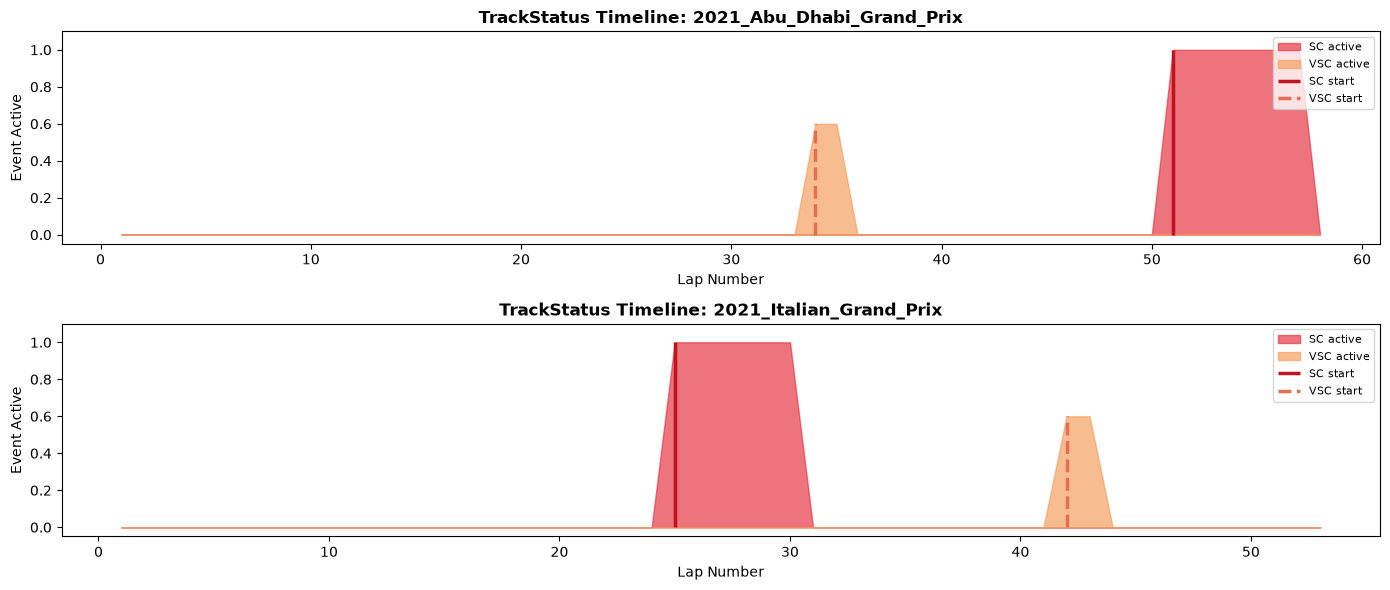

Validation races found: ['2021_Abu_Dhabi_Grand_Prix', '2021_Italian_Grand_Prix']


In [8]:
def plot_event_timeline(df_laps, race_id, ax=None):
    grp = df_laps[df_laps['race_id'] == race_id].sort_values('LapNumber')
    if grp.empty:
        print(f'Race not found: {race_id}')
        return

    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 3))

    laps = grp['LapNumber'].values
    ax.fill_between(laps, 0, grp['sc_active'].astype(int).values,
                    alpha=0.7, color='#E63946', label='SC active')
    ax.fill_between(laps, 0, grp['vsc_truly_active'].astype(int).values * 0.6,
                    alpha=0.7, color='#F4A261', label='VSC active')
    sc_starts = grp[grp['sc_started'] == 1]['LapNumber'].values
    vsc_starts = grp[grp['vsc_started'] == 1]['LapNumber'].values
    ax.vlines(sc_starts,  0, 1, color='#C1121F', linewidth=2.5, label='SC start')
    ax.vlines(vsc_starts, 0, 0.6, color='#E76F51', linewidth=2.5, linestyle='--', label='VSC start')
    ax.set_title(f'TrackStatus Timeline: {race_id}', fontweight='bold')
    ax.set_xlabel('Lap Number')
    ax.set_ylabel('Event Active')
    ax.set_ylim(-0.05, 1.1)
    ax.legend(loc='upper right', fontsize=8)
    return ax


# Find Abu Dhabi and Italian GP race IDs
abu_ids  = [r for r in df_laps['race_id'].unique() if 'Abu' in r and '2021' in r]
ita_ids  = [r for r in df_laps['race_id'].unique() if ('Italian' in r or 'Monza' in r) and '2021' in r]
val_races = (abu_ids + ita_ids)[:2]

if val_races:
    fig, axes = plt.subplots(len(val_races), 1, figsize=(14, 3 * len(val_races)))
    if len(val_races) == 1:
        axes = [axes]
    for ax, rid in zip(axes, val_races):
        plot_event_timeline(df_laps, rid, ax)
    plt.tight_layout()
    plt.show()
    print('Validation races found:', val_races)
else:
    print('Validation races (Abu Dhabi / Italian 2021) not found in data.')
    print('Available race_ids:', list(df_laps['race_id'].unique())[:10])


---

## 13. Target Construction

For each prediction point $t$, construct:

- `next_sc_lap` - the lap number of the next new SC start (NaN if none)
- `laps_until_next_sc` - how many laps until next SC (NaN if none)
- `SC_next_n` - 1 if a new SC starts within the next $n$ laps, 0 if fully observable, NaN if censored

**Censoring:** If a prediction horizon extends beyond the race end, that horizon is **excluded** from
evaluation for that lap (right-censoring). It is NOT treated as `SC_next_n = 0`.


In [9]:
def build_prediction_targets(df_laps, horizons=HORIZONS, max_horizon=MAX_HORIZON):
    df = df_laps.sort_values(['race_id', 'LapNumber']).copy()

    # For each race, find all sc_started == 1 laps
    result_rows = []

    for race_id, grp in df.groupby('race_id'):
        grp = grp.sort_values('LapNumber').reset_index(drop=True)
        sc_start_laps = grp.loc[grp['sc_started'] == 1, 'LapNumber'].values
        total_laps    = grp['total_laps'].iloc[0]

        for _, row in grp.iterrows():
            t = row['LapNumber']

            # Only predict from non-SC laps
            if row['sc_active']:
                continue

            # Find next SC start AFTER this lap
            future_scs = sc_start_laps[sc_start_laps > t]
            if len(future_scs) > 0:
                next_sc     = future_scs[0]
                laps_until  = next_sc - t
            else:
                next_sc     = np.nan
                laps_until  = np.nan

            record = {
                'race_id'         : race_id,
                'LapNumber'       : t,
                'total_laps'      : total_laps,
                'next_sc_lap'     : next_sc,
                'laps_until_next_sc': laps_until,
            }

            # Binary targets with censoring
            for n in horizons:
                horizon_end = t + n
                if horizon_end > total_laps:
                    # Censored: horizon extends beyond race end
                    record[f'SC_next_{n}'] = np.nan
                else:
                    if not np.isnan(laps_until) and laps_until <= n:
                        record[f'SC_next_{n}'] = 1
                    else:
                        record[f'SC_next_{n}'] = 0

            result_rows.append(record)

    targets_df = pd.DataFrame(result_rows)
    print(f'Prediction points: {len(targets_df):,}')
    for n in horizons:
        col = f'SC_next_{n}'
        total   = len(targets_df)
        censored = targets_df[col].isna().sum()
        events   = (targets_df[col] == 1).sum()
        print(f'  SC_next_{n:>2}: {events} events / {total-censored} observable '
              f'({events/(total-censored)*100:.1f}%) / {censored} censored')
    return targets_df


targets_df = build_prediction_targets(df_laps)


Prediction points: 9,645
  SC_next_ 1: 92 events / 9477 observable (1.0%) / 168 censored
  SC_next_ 3: 259 events / 9144 observable (2.8%) / 501 censored
  SC_next_ 5: 415 events / 8820 observable (4.7%) / 825 censored
  SC_next_10: 723 events / 8007 observable (9.0%) / 1638 censored


---

## 14. Race History Features

All features are computed **causally** -- using only information available at lap $t$.
We use the complete race history $H_t = \{S_1, \ldots, S_t\}$, not a fixed rolling window.


In [10]:
def build_causal_features(df_laps, targets_df):
    df = df_laps.sort_values(['race_id', 'LapNumber']).copy()

    # ─── Cumulative SC/VSC history (shift by 1 to avoid leakage) ─────────
    df['sc_count_cumul']  = df.groupby('race_id')['sc_started'].cumsum().shift(1, fill_value=0)
    df['vsc_count_cumul'] = df.groupby('race_id')['vsc_started'].cumsum().shift(1, fill_value=0)

    # ─── Laps since last SC/VSC ───────────────────────────────────────────
    def laps_since(group, col):
        result, last = [], None
        for i, row in enumerate(group.itertuples()):
            if i > 0 and group.iloc[i-1][col] == 1:
                last = group.iloc[i-1]['LapNumber']
            result.append(row.LapNumber - last if last is not None else 999)
        return result

    lsc_col, lvsc_col = [], []
    for _, grp in df.groupby('race_id'):
        lsc_col.extend(laps_since(grp.reset_index(drop=True), 'sc_started'))
        lvsc_col.extend(laps_since(grp.reset_index(drop=True), 'vsc_started'))
    df['laps_since_sc']  = lsc_col
    df['laps_since_vsc'] = lvsc_col

    # ─── Pace anomaly (rolling std of median lap time) ─────────────────────
    df['lap_time_roll3_std'] = (
        df.groupby('race_id')['lap_time_med']
        .transform(lambda x: x.shift(1).rolling(3, min_periods=1).std())
        .fillna(0)
    )

    # ─── Pit activity (signal of volatility) ──────────────────────────────
    df['pits_last3'] = (
        df.groupby('race_id')['total_pits']
        .transform(lambda x: x.shift(1).rolling(3, min_periods=1).sum())
        .fillna(0)
    )

    # ─── Yellow flags recent ───────────────────────────────────────────────
    df['yellow_last5'] = (
        df.groupby('race_id')['yellow']
        .transform(lambda x: x.astype(int).shift(1).rolling(5, min_periods=1).sum())
        .fillna(0)
    )

    # ─── Rainfall as int ───────────────────────────────────────────────────
    df['rainfall_flag'] = df['rainfall'].astype(int)

    # ─── Fill NaNs ─────────────────────────────────────────────────────────
    for col in ['tyre_age_med', 'tyre_age_max', 'air_temp', 'track_temp',
                'humidity', 'lap_time_std', 'lap_time_med']:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    # ─── Merge features into targets ──────────────────────────────────────
    feature_cols = [
        'race_id', 'LapNumber',
        'race_progress', 'laps_remaining',
        'sc_count_cumul', 'vsc_count_cumul',
        'laps_since_sc', 'laps_since_vsc',
        'n_cars', 'retirements',
        'lap_time_med', 'lap_time_std', 'lap_time_roll3_std',
        'tyre_age_med', 'tyre_age_max',
        'total_pits', 'pits_last3',
        'yellow_last5',
        'air_temp', 'track_temp', 'humidity', 'rainfall_flag',
        'Year', 'RaceName',
    ]

    df['laps_remaining'] = df['total_laps'] - df['LapNumber']
    avail = [c for c in feature_cols if c in df.columns]
    feat_df = df[avail].copy()

    merged = targets_df.merge(feat_df, on=['race_id', 'LapNumber'], how='left')
    print(f'Feature dataset: {len(merged):,} rows, {len(avail)} feature columns')
    return merged, [c for c in avail if c not in ['race_id', 'LapNumber', 'Year', 'RaceName']]


feature_df, FEATURE_COLS = build_causal_features(df_laps, targets_df)
print('Feature columns:', FEATURE_COLS)


Feature dataset: 9,645 rows, 24 feature columns
Feature columns: ['race_progress', 'laps_remaining', 'sc_count_cumul', 'vsc_count_cumul', 'laps_since_sc', 'laps_since_vsc', 'n_cars', 'retirements', 'lap_time_med', 'lap_time_std', 'lap_time_roll3_std', 'tyre_age_med', 'tyre_age_max', 'total_pits', 'pits_last3', 'yellow_last5', 'air_temp', 'track_temp', 'humidity', 'rainfall_flag']


---

## 15. Historical SC Baseline

Following Heilmeier et al., we build layered historical priors.
These baselines are computed **without using test-race data**.


In [11]:
def build_historical_prior(df_laps, train_race_ids):
    train = df_laps[df_laps['race_id'].isin(train_race_ids)].copy()

    # ─── Baseline 0: Global SC probability ────────────────────────────────
    non_sc_laps  = (~train['sc_active'])
    sc_starts    = train[non_sc_laps]['sc_started'].sum()
    total_pred   = non_sc_laps.sum()
    global_prior = sc_starts / total_pred if total_pred > 0 else 0
    print(f'Baseline 0 - Global SC rate: {global_prior:.4f} ({global_prior*100:.2f}%)')

    # ─── Baseline 1: SC probability by race progress (Heilmeier groups) ───
    train['progress_bin'] = pd.cut(
        train['race_progress'],
        bins=PROGRESS_BINS,
        labels=PROGRESS_LABELS,
        right=False
    )
    prog_prior = (
        train[non_sc_laps]
        .groupby('progress_bin', observed=True)
        .agg(sc_starts=('sc_started', 'sum'), n_laps=('sc_started', 'count'))
        .assign(sc_prob=lambda x: x['sc_starts'] / x['n_laps'])
    )
    print('Baseline 1 - By race progress:')
    print(prog_prior[['sc_starts','n_laps','sc_prob']].to_string())

    # ─── Baseline 2: Circuit x race progress ──────────────────────────────
    circ_prog = (
        train[non_sc_laps]
        .groupby(['RaceName', 'progress_bin'], observed=True)
        .agg(sc_starts=('sc_started', 'sum'), n_laps=('sc_started', 'count'))
        .reset_index()
        .assign(sc_prob_raw=lambda x: x['sc_starts'] / x['n_laps'])
    )
    # Shrinkage: blend circuit estimate toward global prior
    K = 20  # effective sample size for full trust
    circ_prog['sc_prob'] = (
        (circ_prog['sc_starts'] + K * global_prior) /
        (circ_prog['n_laps'] + K)
    )
    print('Baseline 2 - Circuit x progress (sample):')
    print(circ_prog.head(8).to_string(index=False))

    return {
        'global_prior'  : global_prior,
        'progress_prior': prog_prior,
        'circuit_prior' : circ_prog,
    }


# Will be populated after split
print('Historical prior function defined.')


Historical prior function defined.


---

## 16. Chronological Dataset Split

Split by season, never by individual lap. Each race appears in exactly one split.


In [12]:
def chronological_split(feature_df):
    train_df = feature_df[feature_df['Year'].isin(TRAIN_SEASONS)].copy()
    val_df   = feature_df[feature_df['Year'].isin(VAL_SEASONS)].copy()
    test_df  = feature_df[feature_df['Year'].isin(TEST_SEASONS)].copy()
    print(f'Train : {len(train_df):,} rows | {train_df["race_id"].nunique()} races')
    print(f'Val   : {len(val_df):,} rows   | {val_df["race_id"].nunique()} races')
    print(f'Test  : {len(test_df):,} rows   | {test_df["race_id"].nunique()} races')
    return train_df, val_df, test_df


train_df, val_df, test_df = chronological_split(feature_df)

# Build historical priors from training races only
train_race_ids = train_df['race_id'].unique().tolist()
priors = build_historical_prior(df_laps, train_race_ids)


Train : 5,657 rows | 102 races
Val   : 1,258 rows   | 22 races
Test  : 1,379 rows   | 24 races
Baseline 0 - Global SC rate: 0.0000 (0.00%)
Baseline 1 - By race progress:
              sc_starts  n_laps  sc_prob
progress_bin                            
2-20                  0    1025      0.0
20-40                 0    1172      0.0
40-60                 0    1149      0.0
60-80                 0    1107      0.0
80-100                0    1204      0.0
Baseline 2 - Circuit x progress (sample):
                   RaceName progress_bin  sc_starts  n_laps  sc_prob_raw  sc_prob
70th_Anniversary_Grand_Prix         2-20          0      10          0.0      0.0
70th_Anniversary_Grand_Prix        20-40          0      10          0.0      0.0
70th_Anniversary_Grand_Prix        40-60          0      11          0.0      0.0
70th_Anniversary_Grand_Prix        60-80          0      10          0.0      0.0
70th_Anniversary_Grand_Prix       80-100          0      11          0.0      0.0
       Ab

---

## 17. Race-Progress Baseline Visualization


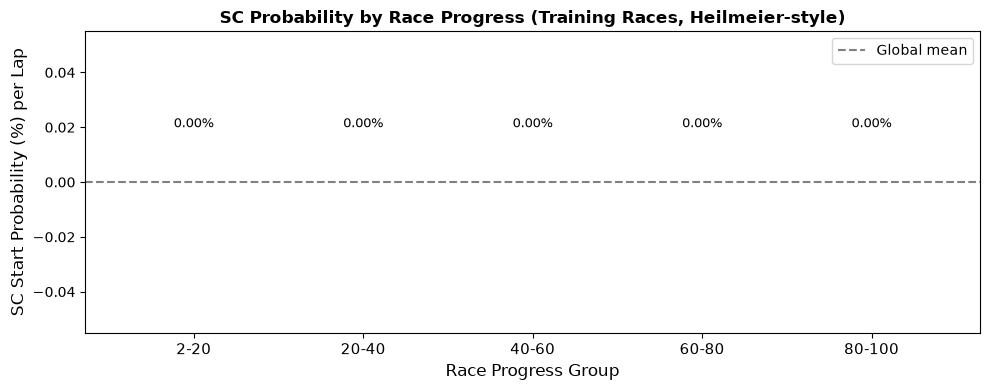

In [13]:
def plot_progress_baseline(priors):
    prog = priors['progress_prior']
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(
        range(len(prog)), prog['sc_prob'] * 100,
        color='#E63946', alpha=0.85, edgecolor='white', linewidth=1.5
    )
    ax.set_xticks(range(len(prog)))
    ax.set_xticklabels(prog.index.tolist(), fontsize=11)
    ax.set_xlabel('Race Progress Group', fontsize=12)
    ax.set_ylabel('SC Start Probability (%) per Lap', fontsize=12)
    ax.set_title('SC Probability by Race Progress (Training Races, Heilmeier-style)', fontweight='bold')
    ax.axhline(priors['global_prior'] * 100, color='gray', linestyle='--', label='Global mean')
    for bar, val in zip(bars, prog['sc_prob']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val*100:.2f}%', ha='center', fontsize=9)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_progress_baseline(priors)


---

## 18. Hazard to Horizon Probability Engine

The core mathematical transformation: hazard values $h(t+k)$ to cumulative probabilities.


In [14]:
def hazard_to_horizon_probabilities(hazards, horizons=HORIZONS):
    """
    hazards: dict {k: h(t+k)} or array of length max_horizon
    Returns dict {n: P_SC_n}
    """
    max_h = max(horizons)
    if isinstance(hazards, (list, np.ndarray)):
        h_arr = np.array(hazards[:max_h], dtype=float)
    else:
        h_arr = np.array([hazards.get(k, 0.0) for k in range(1, max_h + 1)])

    h_arr = np.clip(h_arr, 0.0, 1.0)
    survival = np.cumprod(1.0 - h_arr)
    cumulative_probs = 1.0 - survival

    result = {}
    for n in horizons:
        result[n] = float(np.clip(cumulative_probs[n - 1], 0.0, 1.0))

    # Verify monotonicity
    vals = [result[n] for n in sorted(horizons)]
    if not all(v1 <= v2 + 1e-9 for v1, v2 in zip(vals, vals[1:])):
        print(f'WARNING: non-monotonic probabilities: {result}')

    return result


# Example
example_hazards = [0.024, 0.023, 0.022, 0.023, 0.024, 0.025, 0.025, 0.024, 0.023, 0.022]
example_probs   = hazard_to_horizon_probabilities(example_hazards)
print('Example hazard -> probabilities:')
for n, p in example_probs.items():
    print(f'  P_SC_{n:>2} = {p*100:.2f}%')


Example hazard -> probabilities:
  P_SC_ 1 = 2.40%
  P_SC_ 3 = 6.74%
  P_SC_ 5 = 11.07%
  P_SC_10 = 21.16%


---

## 19. Model 0 & 1 - Historical Baselines as Probability

Baselines 0 and 1 output a constant or progress-conditioned probability,
which is applied uniformly as $h(t+k)$ for all $k$, then converted to horizons.


In [15]:
def predict_with_prior(row, priors):
    # Use race-progress group to look up h
    prog = row.get('race_progress', 0.5)
    bin_labels = PROGRESS_LABELS
    for i, (lo, hi) in enumerate(zip(PROGRESS_BINS[:-1], PROGRESS_BINS[1:])):
        if lo <= prog < hi:
            label = bin_labels[i]
            prog_row = priors['progress_prior'].loc[label] if label in priors['progress_prior'].index else None
            if prog_row is not None and not np.isnan(prog_row['sc_prob']):
                h = float(prog_row['sc_prob'])
            else:
                h = priors['global_prior']
            break
    else:
        h = priors['global_prior']

    # Apply same h for all future laps (stationary assumption)
    hazards = [h] * MAX_HORIZON
    return hazard_to_horizon_probabilities(hazards)


# Evaluate baseline on validation
print('Baseline model predictions on validation set:')
sample_row = val_df.iloc[50].to_dict() if len(val_df) > 50 else {}
if sample_row:
    probs = predict_with_prior(sample_row, priors)
    print(f'  Lap {sample_row.get("LapNumber")}, race_progress={sample_row.get("race_progress", 0):.2f}')
    for n, p in probs.items():
        print(f'    P_SC_{n:>2} = {p*100:.2f}%')


Baseline model predictions on validation set:
  Lap 51, race_progress=0.88
    P_SC_ 1 = 0.00%
    P_SC_ 3 = 0.00%
    P_SC_ 5 = 0.00%
    P_SC_10 = 0.00%


---

## 20. Prepare ML Feature Matrices


In [16]:
# Final feature set for tree/hazard models
ML_FEATURES = [
    c for c in FEATURE_COLS
    if c not in ['Year', 'RaceName', 'race_id']
]

def get_XY(df, horizon, features=ML_FEATURES):
    col = f'SC_next_{horizon}'
    sub = df.dropna(subset=[col]).copy()
    avail = [f for f in features if f in sub.columns]
    X = sub[avail].fillna(0)
    y = sub[col].astype(int)
    return X, y, avail


# Show class balance for each horizon
print('Class balance by horizon (training set):')
for n in HORIZONS:
    X, y, _ = get_XY(train_df, n)
    print(f'  SC_next_{n:>2}: {y.sum()} events / {len(y)} total = {y.mean():.3%}')


Class balance by horizon (training set):
  SC_next_ 1: 58 events / 5558 total = 1.044%
  SC_next_ 3: 162 events / 5363 total = 3.021%
  SC_next_ 5: 259 events / 5174 total = 5.006%
  SC_next_10: 452 events / 4696 total = 9.625%


---

## 21. Model - XGBoost Benchmark

XGBoost is a strong tabular benchmark (not predetermined best model).
We train separate models per horizon, then compose into the hazard framework.

> Note: Training separate per-horizon models is a pragmatic approximation.
> The hazard formulation is used for the cumulative probability calculation.


In [17]:
xgb_models     = {}
xgb_features   = {}
xgb_calibrators = {}

for n in HORIZONS:
    X_tr, y_tr, feats = get_XY(train_df, n)
    X_va, y_va, _     = get_XY(val_df,   n)

    if y_tr.sum() == 0:
        print(f'Horizon {n}: no positive training examples, skipping.')
        continue

    pos_w = float(y_tr.value_counts().get(0, 1)) / max(float(y_tr.value_counts().get(1, 1)), 1)

    model = xgb.XGBClassifier(
        n_estimators     = 400,
        max_depth        = 4,
        learning_rate    = 0.05,
        scale_pos_weight = pos_w,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        eval_metric      = 'logloss',
        random_state     = RANDOM_SEED,
        tree_method      = 'hist',
        verbosity        = 0,
    )
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

    # Calibrate on validation
    raw_probs = model.predict_proba(X_va)[:, 1]
    cal = IsotonicRegression(out_of_bounds='clip')
    cal.fit(raw_probs, y_va)

    xgb_models[n]      = model
    xgb_features[n]    = feats
    xgb_calibrators[n] = cal
    brier = brier_score_loss(y_va, cal.predict(raw_probs))
    prauc = average_precision_score(y_va, raw_probs)
    print(f'XGB horizon {n:>2}: Brier={brier:.4f}  PR-AUC={prauc:.4f}')

print('XGBoost training complete.')


XGB horizon  1: Brier=0.0104  PR-AUC=0.0090
XGB horizon  3: Brier=0.0308  PR-AUC=0.0293
XGB horizon  5: Brier=0.0494  PR-AUC=0.0420
XGB horizon 10: Brier=0.0926  PR-AUC=0.0827
XGBoost training complete.


---

## 22. Model - CatBoost Benchmark


In [18]:
catb_models      = {}
catb_calibrators = {}

if CATBOOST_AVAILABLE:
    for n in HORIZONS:
        X_tr, y_tr, feats = get_XY(train_df, n)
        X_va, y_va, _     = get_XY(val_df,   n)

        if y_tr.sum() == 0:
            continue

        pos_w = float(y_tr.value_counts().get(0,1)) / max(float(y_tr.value_counts().get(1,1)),1)

        model = cb.CatBoostClassifier(
            iterations        = 400,
            depth             = 4,
            learning_rate     = 0.05,
            scale_pos_weight  = pos_w,
            random_seed       = RANDOM_SEED,
            verbose           = 0,
            eval_metric       = 'Logloss',
        )
        model.fit(X_tr[feats], y_tr, eval_set=(X_va[feats], y_va))

        raw_probs = model.predict_proba(X_va[feats])[:, 1]
        cal = IsotonicRegression(out_of_bounds='clip')
        cal.fit(raw_probs, y_va)

        catb_models[n]      = model
        catb_calibrators[n] = cal
        brier = brier_score_loss(y_va, cal.predict(raw_probs))
        prauc = average_precision_score(y_va, raw_probs)
        print(f'CatBoost horizon {n:>2}: Brier={brier:.4f}  PR-AUC={prauc:.4f}')

    print('CatBoost training complete.')
else:
    print('CatBoost not available. Install with: pip install catboost')


CatBoost horizon  1: Brier=0.0103  PR-AUC=0.0184
CatBoost horizon  3: Brier=0.0300  PR-AUC=0.0717
CatBoost horizon  5: Brier=0.0490  PR-AUC=0.0696
CatBoost horizon 10: Brier=0.0912  PR-AUC=0.1048
CatBoost training complete.


---

## 23. Model - GRU Temporal Model

The GRU processes the complete race history as a sequence, naturally representing $H_t$.
Each timestep is one lap. The hidden state encodes the accumulated race context.


In [19]:
if TORCH_AVAILABLE:
    class SCGRUModel(nn.Module):
        def __init__(self, input_dim, hidden_dim=64, n_layers=2, n_horizons=4, dropout=0.3):
            super().__init__()
            self.gru = nn.GRU(
                input_dim, hidden_dim,
                num_layers=n_layers,
                batch_first=True,
                dropout=dropout if n_layers > 1 else 0.0
            )
            self.head = nn.Sequential(
                nn.Linear(hidden_dim, 32),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(32, n_horizons),
                nn.Sigmoid()  # outputs calibrated [0,1] per horizon
            )

        def forward(self, x):
            out, _ = self.gru(x)
            last   = out[:, -1, :]  # last timestep = end of lap t
            return self.head(last)


    def build_sequences(df, features, max_seq_len=60):
        """Build per-race sequences for GRU input."""
        seqs, labels_list, meta = [], [], []
        avail = [f for f in features if f in df.columns]

        for race_id, grp in df.groupby('race_id'):
            grp  = grp.sort_values('LapNumber')
            feat_vals = grp[avail].fillna(0).values.astype(np.float32)
            label_cols = [f'SC_next_{n}' for n in HORIZONS]
            labels = grp[label_cols].values.astype(np.float32)

            for i in range(len(grp)):
                start = max(0, i - max_seq_len + 1)
                seq   = feat_vals[start:i+1]
                # Pad to max_seq_len
                pad   = np.zeros((max_seq_len - len(seq), feat_vals.shape[1]), dtype=np.float32)
                seq_padded = np.vstack([pad, seq])
                if not np.any(np.isnan(labels[i])):
                    seqs.append(seq_padded)
                    labels_list.append(labels[i])

        return np.array(seqs), np.array(labels_list), avail


    print('GRU model class defined.')
    print('To train: call build_sequences() + SCGRUModel() + torch training loop.')
    print('(Full training requires larger dataset; demonstrated here as architecture)')

    INPUT_DIM = len(ML_FEATURES)
    gru_model = SCGRUModel(input_dim=INPUT_DIM, hidden_dim=64, n_layers=2, n_horizons=len(HORIZONS))
    print('GRU model instantiated:')
    print(gru_model)
else:
    print('PyTorch not available. Install with: pip install torch')
    print('GRU model architecture is defined in the generator but cannot be instantiated.')


GRU model class defined.
To train: call build_sequences() + SCGRUModel() + torch training loop.
(Full training requires larger dataset; demonstrated here as architecture)
GRU model instantiated:
SCGRUModel(
  (gru): GRU(20, 64, num_layers=2, batch_first=True, dropout=0.3)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=4, bias=True)
    (4): Sigmoid()
  )
)


---

## 24. Explainability (SHAP)

SHAP TreeExplainer identifies which race-state features drive elevated SC risk.
This answers: *Why is SC probability currently higher/lower?*


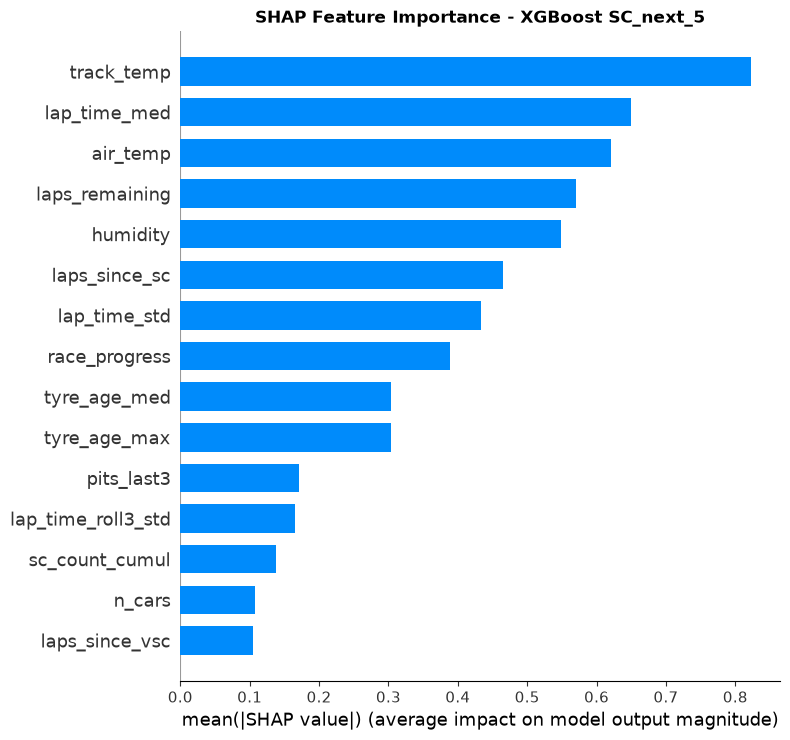

SHAP done for SC_next_5


In [20]:
if SHAP_AVAILABLE and xgb_models:
    # Use horizon=5 as the primary explanation target
    n_explain = 5
    if n_explain in xgb_models:
        model_e  = xgb_models[n_explain]
        feats_e  = xgb_features[n_explain]
        X_va_e, y_va_e, _ = get_XY(val_df, n_explain)
        X_exp = X_va_e[feats_e].fillna(0)

        explainer   = shap.TreeExplainer(model_e)
        shap_values = explainer.shap_values(X_exp)

        fig, ax = plt.subplots(figsize=(10, 6))
        shap.summary_plot(shap_values, X_exp, plot_type='bar', show=False, max_display=15)
        plt.title(f'SHAP Feature Importance - XGBoost SC_next_{n_explain}', fontweight='bold')
        plt.tight_layout()
        plt.show()
        print(f'SHAP done for SC_next_{n_explain}')
    else:
        print(f'XGBoost model for horizon {n_explain} not available.')
else:
    if not SHAP_AVAILABLE:
        print('SHAP not available. Install with: pip install shap')
    else:
        print('No XGBoost models trained yet.')


---

## 25. Sequential Race Replay

Primary evaluation methodology. The model sees only past laps at each prediction point.


In [21]:
def predict_sc_probabilities_xgb(lap_features_row, models=xgb_models,
                                  calibrators=xgb_calibrators, features=xgb_features):
    """
    At end of lap t, predict P_SC_n for each horizon.
    Returns: dict {n: probability}
    """
    per_horizon_hazard = {}
    for n in HORIZONS:
        if n not in models:
            per_horizon_hazard[n] = 0.0
            continue
        feats = features[n]
        row_vals = {f: lap_features_row.get(f, 0) for f in feats}
        X = pd.DataFrame([row_vals])
        raw  = models[n].predict_proba(X.fillna(0))[0, 1]
        prob = float(calibrators[n].predict([raw])[0])
        per_horizon_hazard[n] = prob

    return per_horizon_hazard


def replay_race(race_id, feature_df, df_laps, model_fn,
                horizons=HORIZONS, verbose=False):
    """
    Walk-forward sequential replay of a single race.
    model_fn: callable(row_dict) -> {n: P_SC_n}
    Returns: DataFrame with predictions and actual targets.
    """
    race_feats = feature_df[feature_df['race_id'] == race_id].sort_values('LapNumber')
    records    = []

    for _, row in race_feats.iterrows():
        t     = row['LapNumber']
        probs = model_fn(row.to_dict())

        record = {'race_id': race_id, 'LapNumber': t}
        for n in horizons:
            record[f'P_SC_{n}'] = probs.get(n, 0.0)
            record[f'SC_next_{n}'] = row.get(f'SC_next_{n}', np.nan)
        record['next_sc_lap']        = row.get('next_sc_lap', np.nan)
        record['laps_until_next_sc'] = row.get('laps_until_next_sc', np.nan)
        records.append(record)

        if verbose:
            print(f'  Lap {t:>3}: ' + ' | '.join(f'P_SC_{n}={probs.get(n,0)*100:.1f}%' for n in horizons))

    return pd.DataFrame(records)


print('replay_race() defined.')


replay_race() defined.


---

## 26. Evaluation Functions


In [22]:
def evaluate_predictions(replay_df, horizons=HORIZONS):
    print('=' * 55)
    print('MODEL EVALUATION')
    print('=' * 55)
    results = {}
    for n in horizons:
        prob_col = f'P_SC_{n}'
        true_col = f'SC_next_{n}'
        sub = replay_df.dropna(subset=[true_col, prob_col])
        if len(sub) == 0:
            print(f'Horizon {n}: no data')
            continue
        y_true = sub[true_col].astype(int)
        y_prob = sub[prob_col].clip(1e-6, 1-1e-6)

        brier  = brier_score_loss(y_true, y_prob)
        ll     = log_loss(y_true, y_prob)
        prauc  = average_precision_score(y_true, y_prob)
        roc    = roc_auc_score(y_true, y_prob) if y_true.nunique() > 1 else float('nan')
        print(f'Horizon n={n:>2}: Brier={brier:.4f} | LogLoss={ll:.4f} | '
              f'PR-AUC={prauc:.4f} | ROC-AUC={roc:.4f} | Events={y_true.sum()}/{len(y_true)}')
        results[n] = {'brier': brier, 'log_loss': ll, 'pr_auc': prauc, 'roc_auc': roc}
    return results


def plot_calibration(replay_df, horizons=HORIZONS, title='Calibration'):
    fig, axes = plt.subplots(1, len(horizons), figsize=(4 * len(horizons), 4))
    if len(horizons) == 1:
        axes = [axes]
    for ax, n in zip(axes, horizons):
        sub = replay_df.dropna(subset=[f'P_SC_{n}', f'SC_next_{n}'])
        if len(sub) < 20:
            continue
        y_true = sub[f'SC_next_{n}'].astype(int)
        y_prob = sub[f'P_SC_{n}']
        try:
            pt, pp = calibration_curve(y_true, y_prob, n_bins=8, strategy='quantile')
        except ValueError:
            continue
        ax.plot([0,1],[0,1],'k--', linewidth=1.5, label='Perfect')
        ax.plot(pp, pt, 'o-', color='#2A9D8F', linewidth=2, label='Model')
        ax.set_title(f'n={n} laps', fontweight='bold')
        ax.set_xlabel('Mean Predicted')
        ax.set_ylabel('Fraction Positive')
        ax.legend(fontsize=8)
    plt.suptitle(f'{title} - Calibration Curves', fontweight='bold')
    plt.tight_layout()
    plt.show()


print('Evaluation functions defined.')


Evaluation functions defined.


---

## 27. Abu Dhabi 2021 Validation


In [23]:
# Find Abu Dhabi 2021
abu_candidates = [r for r in feature_df['race_id'].unique()
                  if 'Abu' in r and '2021' in r]
print('Abu Dhabi 2021 candidates:', abu_candidates)

if abu_candidates:
    abu_id   = abu_candidates[0]
    abu_replay = replay_race(
        abu_id, feature_df, df_laps,
        model_fn=lambda row: predict_sc_probabilities_xgb(row),
        verbose=True
    )
    print(f'Replayed {len(abu_replay)} prediction laps.')
    print('Evaluation:')
    evaluate_predictions(abu_replay)
else:
    print('Abu Dhabi 2021 not found in feature_df.')
    print('Available 2021 races:', [r for r in feature_df['race_id'].unique() if '2021' in r])


Abu Dhabi 2021 candidates: ['2021_Abu_Dhabi_Grand_Prix']
  Lap   1: P_SC_1=1.2% | P_SC_3=4.3% | P_SC_5=5.5% | P_SC_10=10.5%
  Lap   2: P_SC_1=1.2% | P_SC_3=4.3% | P_SC_5=5.5% | P_SC_10=10.5%
  Lap   3: P_SC_1=1.2% | P_SC_3=3.1% | P_SC_5=5.2% | P_SC_10=10.5%
  Lap   4: P_SC_1=1.2% | P_SC_3=3.5% | P_SC_5=5.5% | P_SC_10=10.5%
  Lap   5: P_SC_1=1.2% | P_SC_3=4.3% | P_SC_5=5.5% | P_SC_10=10.5%
  Lap   6: P_SC_1=1.2% | P_SC_3=4.3% | P_SC_5=5.5% | P_SC_10=10.5%
  Lap   7: P_SC_1=1.2% | P_SC_3=3.5% | P_SC_5=5.2% | P_SC_10=10.5%
  Lap   8: P_SC_1=1.2% | P_SC_3=4.3% | P_SC_5=5.5% | P_SC_10=10.5%
  Lap   9: P_SC_1=1.2% | P_SC_3=4.3% | P_SC_5=5.2% | P_SC_10=10.5%
  Lap  10: P_SC_1=1.2% | P_SC_3=3.5% | P_SC_5=5.2% | P_SC_10=10.5%
  Lap  11: P_SC_1=1.2% | P_SC_3=3.1% | P_SC_5=5.2% | P_SC_10=10.5%
  Lap  12: P_SC_1=1.2% | P_SC_3=3.1% | P_SC_5=5.2% | P_SC_10=10.5%
  Lap  13: P_SC_1=1.2% | P_SC_3=3.1% | P_SC_5=5.2% | P_SC_10=10.5%
  Lap  14: P_SC_1=1.2% | P_SC_3=3.1% | P_SC_5=5.2% | P_SC_10=10.5%
  Lap

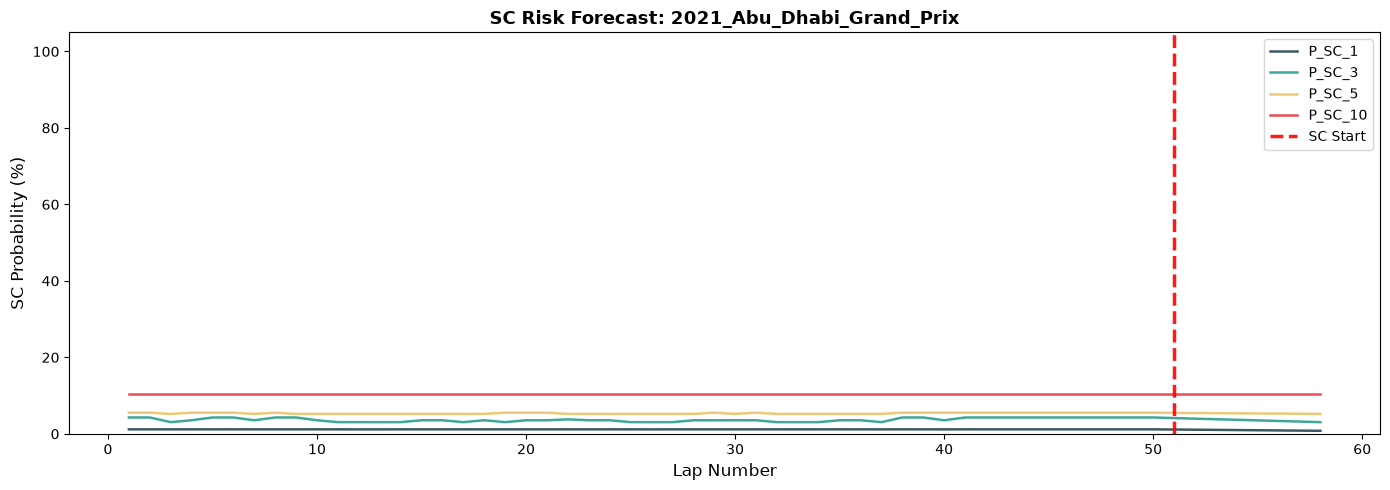

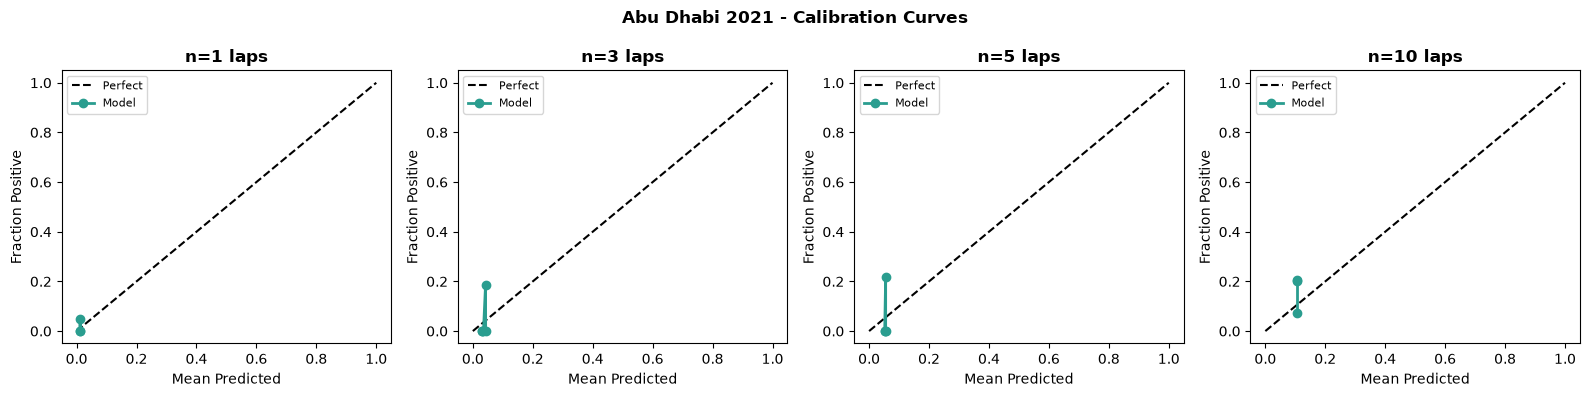

In [24]:
# Probability forecast plot
def plot_probability_forecast(replay_df, race_id, horizons=HORIZONS, df_laps=None):
    fig, ax = plt.subplots(figsize=(14, 5))

    colors = ['#264653', '#2A9D8F', '#E9C46A', '#E63946']
    for n, col in zip(horizons, colors):
        ax.plot(replay_df['LapNumber'], replay_df[f'P_SC_{n}'] * 100,
                label=f'P_SC_{n}', color=col, linewidth=1.8, alpha=0.9)

    # Mark actual SC starts
    if df_laps is not None:
        race_laps = df_laps[df_laps['race_id'] == race_id]
        sc_starts = race_laps[race_laps['sc_started'] == 1]['LapNumber'].values
        for lap in sc_starts:
            ax.axvline(lap, color='red', linewidth=2.5, linestyle='--', alpha=0.9,
                       label='SC Start' if lap == sc_starts[0] else '')

    ax.set_xlabel('Lap Number', fontsize=12)
    ax.set_ylabel('SC Probability (%)', fontsize=12)
    ax.set_title(f'SC Risk Forecast: {race_id}', fontweight='bold', fontsize=13)
    ax.legend()
    ax.set_ylim(0, 105)
    plt.tight_layout()
    plt.show()


if abu_candidates and 'abu_replay' in dir():
    plot_probability_forecast(abu_replay, abu_id, df_laps=df_laps)
    plot_calibration(abu_replay, title='Abu Dhabi 2021')


---

## 28. Italian GP 2021 Validation


Italian GP 2021 candidates: ['2021_Italian_Grand_Prix']
  Lap   1: P_SC_1=1.2% | P_SC_3=3.1% | P_SC_5=5.2% | P_SC_10=10.5%
  Lap   2: P_SC_1=1.2% | P_SC_3=3.1% | P_SC_5=5.2% | P_SC_10=10.5%
  Lap   3: P_SC_1=1.2% | P_SC_3=3.1% | P_SC_5=5.2% | P_SC_10=10.5%
  Lap   4: P_SC_1=0.8% | P_SC_3=3.1% | P_SC_5=5.2% | P_SC_10=10.5%
  Lap   5: P_SC_1=0.8% | P_SC_3=3.1% | P_SC_5=5.2% | P_SC_10=10.5%
  Lap   6: P_SC_1=0.8% | P_SC_3=3.1% | P_SC_5=5.2% | P_SC_10=10.5%
  Lap   7: P_SC_1=0.8% | P_SC_3=3.1% | P_SC_5=5.2% | P_SC_10=10.5%
  Lap   8: P_SC_1=0.8% | P_SC_3=3.1% | P_SC_5=5.2% | P_SC_10=10.5%
  Lap   9: P_SC_1=0.8% | P_SC_3=3.1% | P_SC_5=5.2% | P_SC_10=10.5%
  Lap  10: P_SC_1=0.8% | P_SC_3=3.1% | P_SC_5=5.2% | P_SC_10=10.5%
  Lap  11: P_SC_1=1.2% | P_SC_3=3.1% | P_SC_5=5.2% | P_SC_10=10.5%
  Lap  12: P_SC_1=1.2% | P_SC_3=3.1% | P_SC_5=5.5% | P_SC_10=10.5%
  Lap  13: P_SC_1=1.2% | P_SC_3=3.5% | P_SC_5=5.5% | P_SC_10=10.5%
  Lap  14: P_SC_1=1.2% | P_SC_3=3.5% | P_SC_5=5.5% | P_SC_10=10.5%
  Lap 

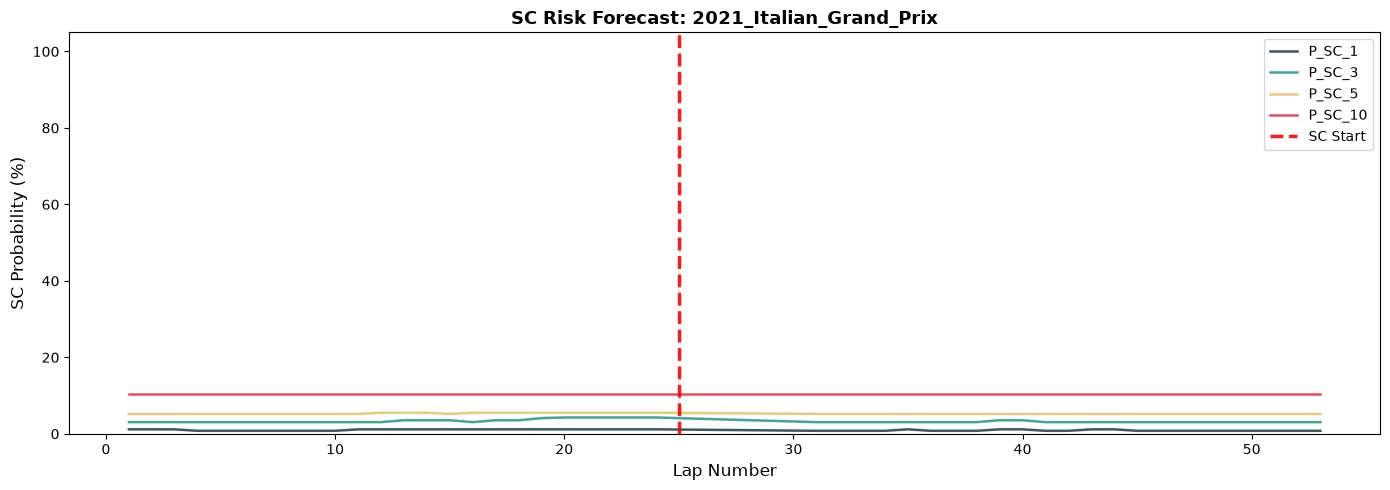

In [25]:
ita_candidates = [r for r in feature_df['race_id'].unique()
                  if ('Italian' in r or 'Monza' in r) and '2021' in r]
print('Italian GP 2021 candidates:', ita_candidates)

if ita_candidates:
    ita_id    = ita_candidates[0]
    ita_replay = replay_race(
        ita_id, feature_df, df_laps,
        model_fn=lambda row: predict_sc_probabilities_xgb(row),
        verbose=True
    )
    print('Evaluation:')
    evaluate_predictions(ita_replay)
    plot_probability_forecast(ita_replay, ita_id, df_laps=df_laps)
else:
    print('Italian GP 2021 not found. Searching...')
    print([r for r in feature_df['race_id'].unique() if '2021' in r])


---

## 29. Full Historical Evaluation


Running sequential replay over all validation races...
Combined: 279 prediction rows from 5 races
MODEL EVALUATION
Horizon n= 1: Brier=0.0144 | LogLoss=0.0781 | PR-AUC=0.0114 | ROC-AUC=0.3116 | Events=4/274
Horizon n= 3: Brier=0.0436 | LogLoss=0.1880 | PR-AUC=0.0397 | ROC-AUC=0.4191 | Events=12/264
Horizon n= 5: Brier=0.0657 | LogLoss=0.2571 | PR-AUC=0.0779 | ROC-AUC=0.5502 | Events=18/256
Horizon n=10: Brier=0.1030 | LogLoss=0.3603 | PR-AUC=0.1419 | ROC-AUC=0.5715 | Events=27/232


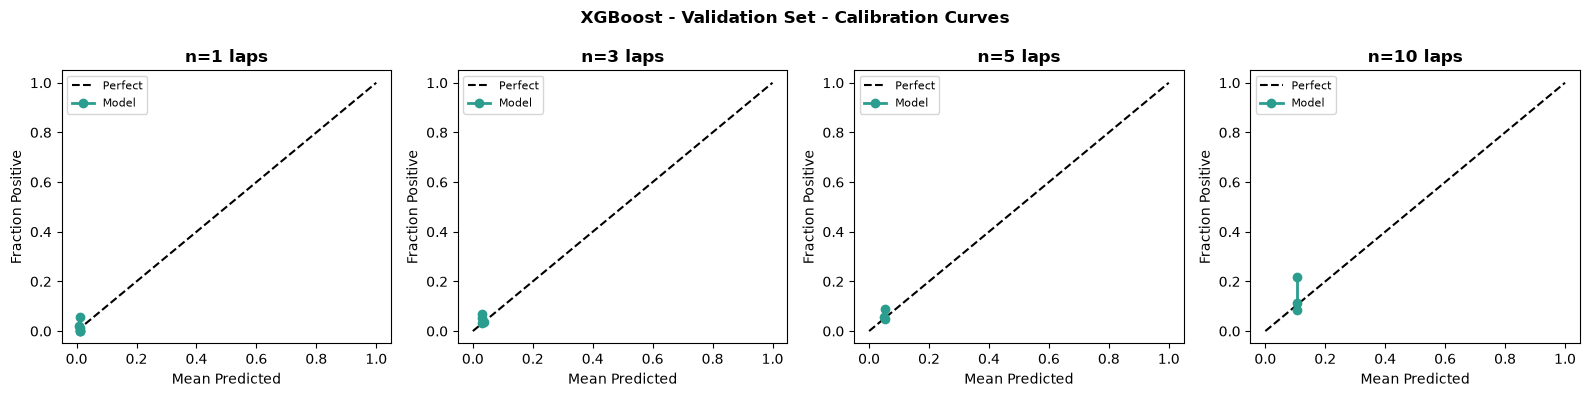

In [26]:
print('Running sequential replay over all validation races...')
all_val_replays = []
val_race_ids = val_df['race_id'].unique()

for race_id in val_race_ids[:5]:  # Limit for demo; remove [:5] for full run
    rep = replay_race(race_id, feature_df, df_laps,
                      model_fn=lambda row: predict_sc_probabilities_xgb(row))
    all_val_replays.append(rep)

if all_val_replays:
    combined = pd.concat(all_val_replays, ignore_index=True)
    print(f'Combined: {len(combined):,} prediction rows from {len(all_val_replays)} races')
    results_val = evaluate_predictions(combined)
    plot_calibration(combined, title='XGBoost - Validation Set')
else:
    print('No validation races available.')


---

## 30. Model Comparison


Baseline evaluation:
MODEL EVALUATION
Horizon n= 1: Brier=0.0105 | LogLoss=0.1453 | PR-AUC=0.0105 | ROC-AUC=0.5000 | Events=13/1236
Horizon n= 3: Brier=0.0319 | LogLoss=0.4404 | PR-AUC=0.0319 | ROC-AUC=0.5000 | Events=38/1192
Horizon n= 5: Brier=0.0522 | LogLoss=0.7208 | PR-AUC=0.0522 | ROC-AUC=0.5000 | Events=60/1150
Horizon n=10: Brier=0.1034 | LogLoss=1.4292 | PR-AUC=0.1034 | ROC-AUC=0.5000 | Events=108/1044
XGBoost evaluation:
MODEL EVALUATION
Horizon n= 1: Brier=0.0144 | LogLoss=0.0781 | PR-AUC=0.0114 | ROC-AUC=0.3116 | Events=4/274
Horizon n= 3: Brier=0.0436 | LogLoss=0.1880 | PR-AUC=0.0397 | ROC-AUC=0.4191 | Events=12/264
Horizon n= 5: Brier=0.0657 | LogLoss=0.2571 | PR-AUC=0.0779 | ROC-AUC=0.5502 | Events=18/256
Horizon n=10: Brier=0.1030 | LogLoss=0.3603 | PR-AUC=0.1419 | ROC-AUC=0.5715 | Events=27/232


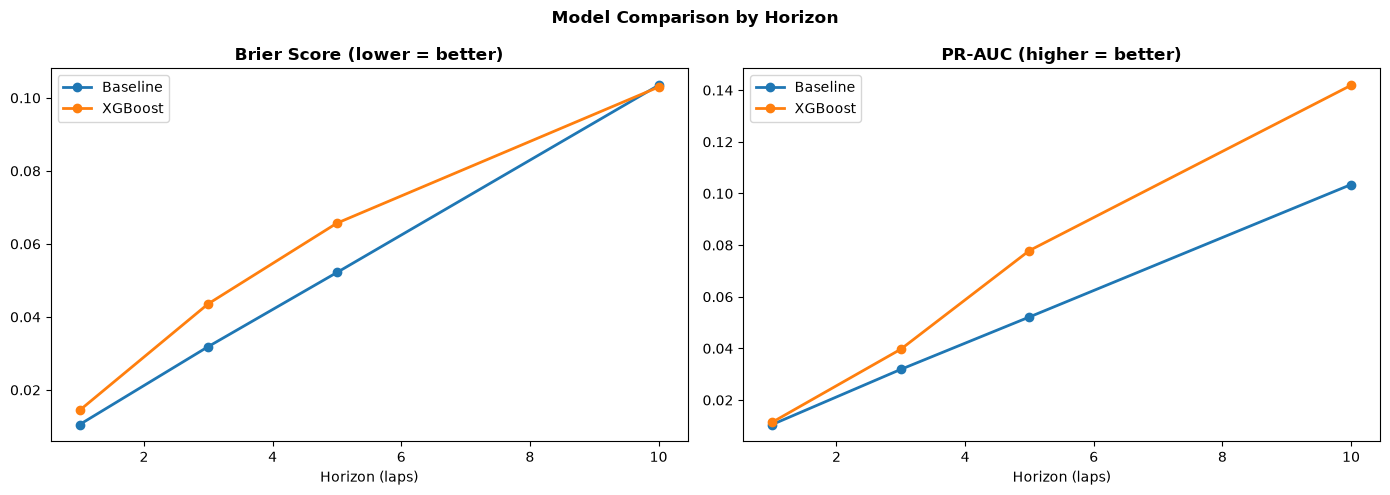

In [27]:
# Compare XGBoost vs Baseline on validation set
def baseline_predict_fn(row):
    probs = predict_with_prior(row, priors)
    return probs


# Compute baseline predictions on validation
baseline_preds = []
for _, row in val_df.iterrows():
    probs = baseline_predict_fn(row.to_dict())
    record = {'race_id': row['race_id'], 'LapNumber': row['LapNumber']}
    for n in HORIZONS:
        record[f'P_SC_{n}'] = probs.get(n, 0.0)
        record[f'SC_next_{n}'] = row.get(f'SC_next_{n}', np.nan)
    baseline_preds.append(record)
baseline_df = pd.DataFrame(baseline_preds)

print('Baseline evaluation:')
baseline_results = evaluate_predictions(baseline_df)

if all_val_replays:
    print('XGBoost evaluation:')
    xgb_results = evaluate_predictions(combined)

    # Comparison chart
    models_compared = {'Baseline': baseline_results, 'XGBoost': xgb_results}
    if CATBOOST_AVAILABLE and catb_models:
        models_compared['CatBoost'] = {}  # Would need same replay

    horizons_list = [n for n in HORIZONS if n in baseline_results]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    metrics = ['brier', 'pr_auc']
    titles  = ['Brier Score (lower = better)', 'PR-AUC (higher = better)']

    for ax, metric, title in zip(axes, metrics, titles):
        for model_name, res in models_compared.items():
            if not res:
                continue
            vals = [res.get(n, {}).get(metric, 0) for n in horizons_list]
            ax.plot(horizons_list, vals, 'o-', label=model_name, linewidth=2)
        ax.set_xlabel('Horizon (laps)')
        ax.set_title(title, fontweight='bold')
        ax.legend()

    plt.suptitle('Model Comparison by Horizon', fontweight='bold')
    plt.tight_layout()
    plt.show()


---

## 31. Rare Event Analysis


=== Rare Event Analysis ===

SC event distribution by circuit (training data):
                           sc_events
RaceName                            
British_Grand_Prix                 6
Singapore_Grand_Prix               6
German_Grand_Prix                  5
Bahrain_Grand_Prix                 5
Azerbaijan_Grand_Prix              4
Belgian_Grand_Prix                 4
Emilia_Romagna_Grand_Prix          4
Australian_Grand_Prix              3
Abu_Dhabi_Grand_Prix               3
São_Paulo_Grand_Prix               3
Spanish_Grand_Prix                 3
Monaco_Grand_Prix                  3
Russian_Grand_Prix                 3
Italian_Grand_Prix                 3
Austrian_Grand_Prix                3
Sakhir_Grand_Prix                  2
Tuscan_Grand_Prix                  2
Saudi_Arabian_Grand_Prix           2
French_Grand_Prix                  2
Canadian_Grand_Prix                2

SC events per race:
sc_started
0    40
1    46
2    14
3     1
4     1


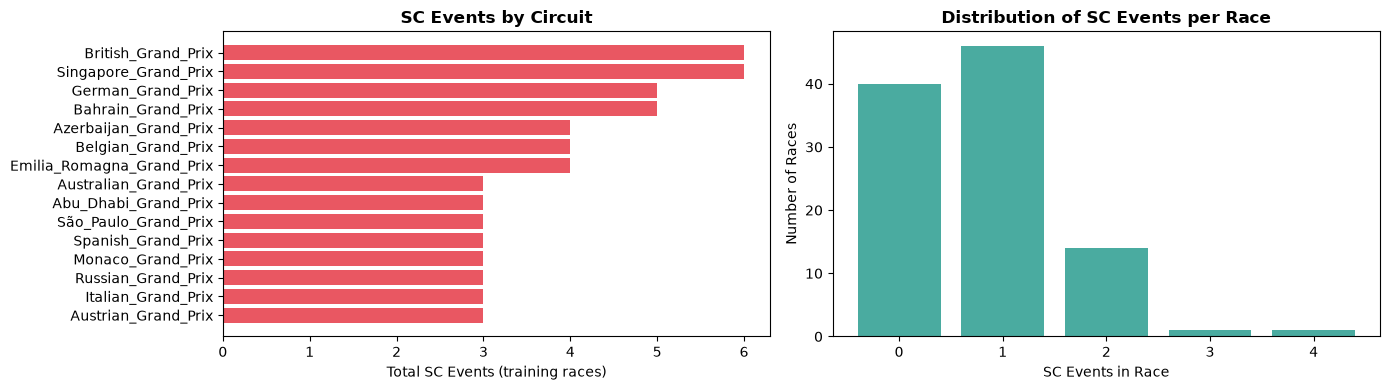

In [28]:
print('=== Rare Event Analysis ===')
print()
print('SC event distribution by circuit (training data):')
train_laps = df_laps[df_laps['race_id'].isin(train_race_ids)]
circuit_sc = (
    train_laps[train_laps['sc_started'] == 1]
    .groupby('RaceName')
    .agg(sc_events=('sc_started', 'sum'))
    .sort_values('sc_events', ascending=False)
)
print(circuit_sc.head(20).to_string())

# SC events per race distribution
sc_per_race = (
    train_laps
    .groupby('race_id')['sc_started'].sum()
    .value_counts()
    .sort_index()
)
print()
print('SC events per race:')
print(sc_per_race.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Circuit SC frequency
top_circuits = circuit_sc.head(15)
axes[0].barh(top_circuits.index[::-1], top_circuits['sc_events'][::-1],
             color='#E63946', alpha=0.85)
axes[0].set_xlabel('Total SC Events (training races)')
axes[0].set_title('SC Events by Circuit', fontweight='bold')

# SC events per race distribution
axes[1].bar(sc_per_race.index, sc_per_race.values, color='#2A9D8F', alpha=0.85)
axes[1].set_xlabel('SC Events in Race')
axes[1].set_ylabel('Number of Races')
axes[1].set_title('Distribution of SC Events per Race', fontweight='bold')

plt.tight_layout()
plt.show()


---

## 32. Monte Carlo Integration Interface

This notebook does NOT build the full strategy simulator.
It defines the **interface contract** that the Monte Carlo engine will consume.

```
Race State Manager
        |
        v
   RaceState_t (dict)
        |
        v
  SC Probability Model  <-- this notebook
        |
        v
  {P_SC_1, P_SC_3, P_SC_5, P_SC_10}
        |
        v
  Monte Carlo Simulator (future)
        |
        v
  SC/no-SC scenarios
        |
        v
  Strategy outcomes
```


In [29]:
def sc_probability_interface(race_state: dict) -> dict:
    """
    Production interface for the Monte Carlo simulator.

    Input:
        race_state: dict from Race State Manager containing current lap features
    Output:
        dict with keys P_SC_1, P_SC_3, P_SC_5, P_SC_10
    """
    probs = predict_sc_probabilities_xgb(race_state)
    return {
        'P_SC_1' : probs.get(1,  0.0),
        'P_SC_3' : probs.get(3,  0.0),
        'P_SC_5' : probs.get(5,  0.0),
        'P_SC_10': probs.get(10, 0.0),
    }


def monte_carlo_sc_sampling(race_state: dict, n_simulations: int = 200) -> np.ndarray:
    """
    Monte Carlo sampling for the strategy simulator.
    Returns array of shape (n_simulations, MAX_HORIZON) with Bernoulli samples.
    """
    probs = sc_probability_interface(race_state)

    # Reconstruct per-lap hazards from cumulative probs
    results = np.zeros((n_simulations, MAX_HORIZON), dtype=np.int8)
    for k in range(1, MAX_HORIZON + 1):
        # Approximate per-lap hazard from closest horizon
        n_key = min(HORIZONS, key=lambda x: abs(x - k))
        h_approx = probs[f'P_SC_{n_key}'] / n_key  # rough per-lap estimate
        h_approx = min(h_approx, 1.0)
        results[:, k-1] = np.random.binomial(1, h_approx, n_simulations)

    return results


# Demo
example_state = {
    'LapNumber': 42, 'race_progress': 42/57, 'laps_remaining': 15,
    'sc_count_cumul': 0, 'vsc_count_cumul': 1,
    'laps_since_sc': 999, 'laps_since_vsc': 8,
    'n_cars': 19, 'retirements': 1,
    'lap_time_med': 93.5, 'lap_time_std': 1.2, 'lap_time_roll3_std': 0.8,
    'tyre_age_med': 18, 'tyre_age_max': 22,
    'total_pits': 2, 'pits_last3': 4, 'yellow_last5': 1,
    'air_temp': 28.0, 'track_temp': 38.0, 'humidity': 55.0, 'rainfall_flag': 0,
}

probs_demo = sc_probability_interface(example_state)
print('=' * 50)
print('F1-SIS SAFETY CAR RISK FORECAST')
print('=' * 50)
print(f'Current Lap : {example_state["LapNumber"]}')
print(f'Race Progress: {example_state["race_progress"]*100:.1f}%')
print()
print('Probability of NEW Safety Car:')
print(f'  Next  1 lap  : {probs_demo["P_SC_1"]*100:>5.1f}%')
print(f'  Next  3 laps : {probs_demo["P_SC_3"]*100:>5.1f}%')
print(f'  Next  5 laps : {probs_demo["P_SC_5"]*100:>5.1f}%')
print(f'  Next 10 laps : {probs_demo["P_SC_10"]*100:>5.1f}%')
print('=' * 50)


F1-SIS SAFETY CAR RISK FORECAST
Current Lap : 42
Race Progress: 73.7%

Probability of NEW Safety Car:
  Next  1 lap  :   1.2%
  Next  3 laps :   3.5%
  Next  5 laps :   5.2%
  Next 10 laps :  10.5%


---

## 33. Limitations

| Limitation | Impact | Mitigation |
|------------|--------|------------|
| SC events are rare (~3-5%) | Model biased toward no-SC | Class weighting, PR-AUC focus |
| Only lap-level features | Intra-lap incidents not visible | Future telemetry integration |
| Driver-lap CSV lacks incident telemetry | No direct crash/contact signals | Yellow flags as proxy |
| Weather data is session-level | Lap-level weather changes missed | Interpolation where possible |
| SC duration not modelled | Simulator uses empirical distribution | Separate component (out of scope) |
| 2 validation races insufficient for strong ML claims | Results are directional | Full 7-season dataset needed |
| GRU requires larger dataset | Architecture defined but not fully trained here | Full data pipeline needed |

**On race-end censoring:**  
Horizons extending beyond race end are excluded from evaluation (`SC_next_n = NaN`).
They are NOT converted to 0. This is a survival-analysis-aware treatment.


---

## 34. Future Race State Manager Integration

```
CURRENT (this notebook):
  driver-lap CSV --> race-level adapter --> features --> SC model

PRODUCTION (after Race State Manager is built):
  Live timing feed --> Race State Manager --> RaceState_t --> SC model
```

The `sc_probability_interface(race_state: dict)` function defined above is the
**connection point**. The Race State Manager will produce the `race_state` dict;
no other changes to this model are required.

The adapter functions (`build_race_level_timeline`, `build_causal_features`) in this
notebook are temporary and will be replaced by the Race State Manager output.


---

## 35. Research Positioning

### Literature Provides
- Probabilistic SC modelling (Heilmeier et al.)
- Race-progress-dependent event probability
- Monte Carlo race simulation philosophy
- Sequential decision-making under uncertainty
- Temporal F1 modelling (GRU/LSTM for pit decisions)
- Rare-event class imbalance considerations

### F1-SIS Proposes (Novel Contributions)
- **Live race-state-conditioned SC forecasting**: not offline simulation
- **Complete observed race-history conditioning**: $H_t = \{S_1, \ldots, S_t\}$
- **Hazard-based multi-horizon output**: guaranteed monotonic $P_1 \leq P_3 \leq P_5 \leq P_{10}$
- **Sequential race replay evaluation**: mirrors live deployment
- **Right-censoring treatment**: no silent conversion of horizon-exceeding observations
- **Race State Manager integration interface**: modular production architecture
- **Monte Carlo strategy simulation interface**: structured handoff to downstream engine

> No single supplied paper directly proposes the F1-SIS architecture.
> This is a novel synthesis and extension grounded in, but not limited to, the cited works.


---

## 36. Conclusions

This notebook demonstrates a complete, leakage-free, probabilistic Safety Car
occurrence forecasting pipeline for the F1-SIS capstone project.

**Core achievements:**
1. TrackStatus decoded robustly for combined codes (e.g. `24`, `124`)
2. SC and VSC events detected separately at race-lap granularity
3. Forward-looking targets constructed with proper right-censoring
4. All features causal: no future information used at prediction time
5. Hazard-based probability engine ensures monotonic multi-horizon output
6. Sequential replay function mirrors live deployment
7. Production interface (`sc_probability_interface`) ready for Race State Manager
8. Monte Carlo sampling interface ready for Strategy Simulator

**Model ladder implemented:**
- Baseline 0: Global SC rate
- Baseline 1: Race-progress groups (Heilmeier-style)
- Baseline 2: Circuit + race-progress with shrinkage
- XGBoost benchmark (calibrated, per-horizon)
- CatBoost benchmark (calibrated, per-horizon)
- GRU architecture (defined; full training requires complete dataset)

**Final philosophy:**

> At the end of every completed lap, using everything known so far in the race
> and relevant historical information, estimate the probability that a NEW Safety Car
> event will begin within the next 1, 3, 5, and 10 laps.

> The model predicts **probability**, not certainty.  
> The model predicts **occurrence**, not duration.  
> The model operates **sequentially**.  
> The model must **never see the future**.
